# CS 418 Final Project  
## Media Framing of Palestine  

**Group Name:** 404: Data Not Found  

**Group Members:**  
- Bryan Dominguez  
- Sami Fariz
- Safe Nassan
- Baraa Eldeirawi
- Justin McClain

## Introduction 
This project analyzes how international media frames the Palestine-Israel conflict using news headline data. We examine differences in coverage across countries in terms of volume, timing, and wording patterns. Using NLP techniques such as TF-IDF and machine learning models, we aim to identify patterns in how different countries report on the conflict.

In [ ]:
%pip install pandas numpy matplotlib scikit-learn nltk requests scipy

In [2]:
import os
import re
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from scipy.stats import kruskal

plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)

## Data
We collected 853 news headlines using the GDELT API with keywords such as “Palestine,” “Gaza,” and “West Bank.” The dataset spans from February 1, 2026 to April 29, 2026 and includes sources from countries such as Turkey, Israel, the United States, and Egypt. Each record includes the headline text, country, and publication date.

In [3]:
QUERY = '(Palestine OR Gaza OR "West Bank" OR "Israel conflict")'
RANDOM_STATE = 42

MAX_RECORDS_PER_WINDOW = 250

TIME_WINDOWS = [
    ("20260201000000", "20260215235959"),
    ("20260216000000", "20260228235959"),
    ("20260301000000", "20260315235959"),
    ("20260316000000", "20260331235959"),
    ("20260401000000", "20260415235959"),
    ("20260416000000", "20260430235959"),
]

CACHE_FILE = "gdelt_palestine_feb_apr_2026.csv"
FORCE_REFETCH = True

TOP_N_VIS_COUNTRIES = 4
TOP_N_ML_COUNTRIES = 3

In [4]:
def fetch_gdelt_window(query, start_dt, end_dt, max_records=250):
    base_url = "https://api.gdeltproject.org/api/v2/doc/doc"
    headers = {"User-Agent": "Mozilla/5.0"}

    params = {
        "query": query,
        "mode": "ArtList",
        "format": "json",
        "maxrecords": max_records,
        "STARTDATETIME": start_dt,
        "ENDDATETIME": end_dt,
    }

    for attempt in range(4):
        try:
            response = requests.get(base_url, params=params, headers=headers, timeout=30)
            print(f"{start_dt} to {end_dt} | Attempt {attempt+1} | Status: {response.status_code}")

            if response.status_code == 429:
                wait_time = 10 * (attempt + 1)
                print(f"Rate limited. Waiting {wait_time} seconds...")
                time.sleep(wait_time)
                continue

            response.raise_for_status()

            if not response.text.strip():
                print("Empty response returned.")
                time.sleep(5)
                continue

            try:
                data = response.json()
            except Exception:
                print("Non-JSON response. First 200 characters:")
                print(response.text[:200])
                time.sleep(5)
                continue

            rows = []
            for article in data.get("articles", []):
                rows.append({
                    "title": article.get("title"),
                    "source_country": article.get("sourcecountry"),
                    "date": article.get("seendate"),
                    "url": article.get("url")
                })

            return pd.DataFrame(rows, columns=["title", "source_country", "date", "url"])

        except Exception as e:
            print("Fetch error:", e)
            time.sleep(5)

    return pd.DataFrame(columns=["title", "source_country", "date", "url"])


def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^\w\s]", " ", text, flags=re.UNICODE)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [5]:
if (not FORCE_REFETCH) and os.path.exists(CACHE_FILE):
    raw_df = pd.read_csv(CACHE_FILE)
    print("Loaded cached data:", CACHE_FILE)
else:
    parts = []
    for start_dt, end_dt in TIME_WINDOWS:
        part = fetch_gdelt_window(QUERY, start_dt, end_dt, MAX_RECORDS_PER_WINDOW)
        parts.append(part)
        time.sleep(8)

    raw_df = pd.concat(parts, ignore_index=True)
    raw_df.to_csv(CACHE_FILE, index=False)
    print("Fetched live data and saved cache:", CACHE_FILE)

print("Raw shape:", raw_df.shape)
print("Columns:", raw_df.columns.tolist())
display(raw_df.head())

if raw_df.empty:
    print("raw_df is empty. Leave FORCE_REFETCH=True and rerun only this cell after waiting a minute.")

20260201000000 to 20260215235959 | Attempt 1 | Status: 200
20260216000000 to 20260228235959 | Attempt 1 | Status: 200
20260301000000 to 20260315235959 | Attempt 1 | Status: 200
20260316000000 to 20260331235959 | Attempt 1 | Status: 429
Rate limited. Waiting 10 seconds...
20260316000000 to 20260331235959 | Attempt 2 | Status: 429
Rate limited. Waiting 20 seconds...
20260316000000 to 20260331235959 | Attempt 3 | Status: 429
Rate limited. Waiting 30 seconds...
20260316000000 to 20260331235959 | Attempt 4 | Status: 429
Rate limited. Waiting 40 seconds...
20260401000000 to 20260415235959 | Attempt 1 | Status: 200
20260416000000 to 20260430235959 | Attempt 1 | Status: 200
Fetched live data and saved cache: gdelt_palestine_feb_apr_2026.csv
Raw shape: (1250, 4)
Columns: ['title', 'source_country', 'date', 'url']


,title,source_country,date,url
0,埃及批以色列對約旦河西岸新法 意圖併吞巴人領土 | 國際,Taiwan,20260211T084500Z,https://www.cna.com.tw:443/news/aopl/202602110...
1,埃及批以色列對約旦河西岸新法 意圖併吞巴人領土 | 國際,Taiwan,20260211T084500Z,https://www.cna.com.tw/news/aopl/202602110217....
2,Filistinin BM Daimi Temsilcisi Mansur : Gazze...,Turkey,20260203T174500Z,https://www.haberler.com/guncel/bm-temsilcisi-...
3,"BM Genel Sekreteri Guterres : Gazze , Filisti...",Turkey,20260203T160000Z,http://www.haberler.com/guncel/bm-genel-sekret...
4,Kuruc . info - Továbbra sincs béke Palesztinában,Hungary,20260207T203000Z,https://kuruc.info/r/67/298095/


## Data Cleaning
We cleaned the dataset by removing duplicate articles and filtering out missing values in key fields such as title, source country, and date. We converted dates into a standard datetime format and removed invalid entries.

We also normalized the text by converting headlines to lowercase and removing symbols, creating a `clean_text` column for analysis. Additionally, we filtered out very short headlines to ensure meaningful content for analysis.

This preprocessing ensured consistency and improved the quality of the dataset for both visualization and machine learning tasks.

In [6]:
raw_rows = len(raw_df)

df = raw_df.copy()

df = df.drop_duplicates(subset=["title", "source_country", "date"])
after_dedup = len(df)

df = df.dropna(subset=["title", "source_country", "date"]).copy()
after_missing = len(df)

df["date"] = pd.to_datetime(df["date"], format="%Y%m%dT%H%M%SZ", errors="coerce")
df = df.dropna(subset=["date"]).copy()
after_dates = len(df)

df["clean_text"] = df["title"].apply(clean_text)
df["headline_length_words"] = df["clean_text"].str.split().apply(len)

df = df[df["headline_length_words"] >= 4].copy()
after_min_words = len(df)

print("Rows after cleaning:", len(df))
print("Columns after cleaning:", df.columns.tolist())
display(df.head())

Rows after cleaning: 1112
Columns after cleaning: ['title', 'source_country', 'date', 'url', 'clean_text', 'headline_length_words']


,title,source_country,date,url,clean_text,headline_length_words
2,Filistinin BM Daimi Temsilcisi Mansur : Gazze...,Turkey,2026-02-03 17:45:00,https://www.haberler.com/guncel/bm-temsilcisi-...,filistinin bm daimi temsilcisi mansur gazze fi...,10
3,"BM Genel Sekreteri Guterres : Gazze , Filisti...",Turkey,2026-02-03 16:00:00,http://www.haberler.com/guncel/bm-genel-sekret...,bm genel sekreteri guterres gazze filistin dev...,13
4,Kuruc . info - Továbbra sincs béke Palesztinában,Hungary,2026-02-07 20:30:00,https://kuruc.info/r/67/298095/,kuruc info továbbra sincs béke palesztinában,6
5,الرئيس محمود عباس يُؤكد أهمية الموقف الدولي حي...,Israel,2026-02-11 19:00:00,https://pnn.ps/news/719874,الرئيس محمود عباس ي ؤكد أهمية الموقف الدولي حي...,14
6,以色列又要打一场仗吗 八国谴责领土扩张 _ 军事频道 _ 中华网,China,2026-02-14 08:15:00,https://military.china.com/news/13004177/20260...,以色列又要打一场仗吗 八国谴责领土扩张 _ 军事频道 _ 中华网,6


## Exploratory Data Analysis
We performed exploratory data analysis to better understand the distribution of the dataset. The data is unevenly distributed across countries, with some sources contributing significantly more headlines than others.

To focus our analysis, we selected the top countries with the highest number of articles. We also created a subset for machine learning by balancing the dataset across the top three countries to avoid bias in classification.

Additionally, we examined temporal trends and headline characteristics, which showed that article volume fluctuates over time, likely corresponding to major events.

In [7]:
country_counts_all = df["source_country"].value_counts()

top_countries = country_counts_all.head(TOP_N_VIS_COUNTRIES).index.tolist()

df_selected = df[df["source_country"].isin(top_countries)].copy()
df_selected["month"] = df_selected["date"].dt.to_period("M").astype(str)

# ML subset: top 3 countries, balanced
ml_countries = df_selected["source_country"].value_counts().head(TOP_N_ML_COUNTRIES).index.tolist()
df_ml = df_selected[df_selected["source_country"].isin(ml_countries)].copy()

if df_ml["source_country"].nunique() >= 2:
    min_count = df_ml["source_country"].value_counts().min()
    sampled_parts = []

    for country in ml_countries:
        sampled_parts.append(
            df_ml[df_ml["source_country"] == country].sample(
                n=min_count,
                random_state=RANDOM_STATE
            )
        )

    df_ml = pd.concat(sampled_parts, ignore_index=True)

df_selected.to_csv("cleaned_palestine_headlines_selected.csv", index=False)
df_ml.to_csv("cleaned_palestine_headlines_ml.csv", index=False)

print("Top countries used for visuals:", top_countries)
print("Selected dataset shape:", df_selected.shape)
print(df_selected["source_country"].value_counts())

print("\nCountries used for ML:", ml_countries)
print("ML dataset shape:", df_ml.shape)
if not df_ml.empty:
    print(df_ml["source_country"].value_counts())

Top countries used for visuals: ['Turkey', 'Israel', 'United States', 'Egypt']
Selected dataset shape: (719, 7)
source_country
Turkey           454
Israel           132
United States     67
Egypt             66
Name: count, dtype: int64

Countries used for ML: ['Turkey', 'Israel', 'United States']
ML dataset shape: (201, 7)
source_country
Turkey           67
Israel           67
United States    67
Name: count, dtype: int64


In [8]:
date_min = df_selected["date"].min().date()
date_max = df_selected["date"].max().date()

summary_table = pd.DataFrame({
    "Metric": [
        "Raw collected rows",
        "After duplicate removal",
        "After dropping missing title/date/country",
        "After valid date parsing",
        "After minimum headline-length filtering",
        "Rows in selected dataset",
        "Unique countries in selected dataset",
        "Rows in ML dataset",
        "Average headline length (words)",
        "Minimum date",
        "Maximum date"
    ],
    "Value": [
        raw_rows,
        after_dedup,
        after_missing,
        after_dates,
        after_min_words,
        len(df_selected),
        df_selected["source_country"].nunique(),
        len(df_ml),
        round(df_selected["headline_length_words"].mean(), 2),
        str(date_min),
        str(date_max)
    ]
})

country_table = df_selected["source_country"].value_counts().reset_index()
country_table.columns = ["source_country", "article_count"]

month_table = (
    df_selected.groupby("month")
    .size()
    .reset_index(name="article_count")
    .sort_values("month")
)

display(summary_table)
display(country_table)
display(month_table)

,Metric,Value
0,Raw collected rows,1250
1,After duplicate removal,1164
2,After dropping missing title/date/country,1164
3,After valid date parsing,1164
4,After minimum headline-length filtering,1112
5,Rows in selected dataset,719
6,Unique countries in selected dataset,4
7,Rows in ML dataset,201
8,Average headline length (words),11.0
9,Minimum date,2026-02-01


,source_country,article_count
0,Turkey,454
1,Israel,132
2,United States,67
3,Egypt,66


,month,article_count
0,2026-02,267
1,2026-03,145
2,2026-04,301
3,2026-05,6


## Visualizations
We created visualizations to compare headline coverage across countries. These charts help show differences in coverage volume and topic emphasis.

In [9]:
vis_df = df_selected.copy()

date_start = vis_df["date"].min().date()
date_end = vis_df["date"].max().date()

print("Countries used in visuals:", top_countries)
print("Date range:", date_start, "to", date_end)
print(vis_df["source_country"].value_counts())

Countries used in visuals: ['Turkey', 'Israel', 'United States', 'Egypt']
Date range: 2026-02-01 to 2026-05-01
source_country
Turkey           454
Israel           132
United States     67
Egypt             66
Name: count, dtype: int64


**Visualization 1: Headline Counts by Country**

This chart shows that the selected dataset is unevenly distributed across countries. Turkey contributes the most Palestine-related headlines, while Israel, the United States, and Egypt contribute fewer.

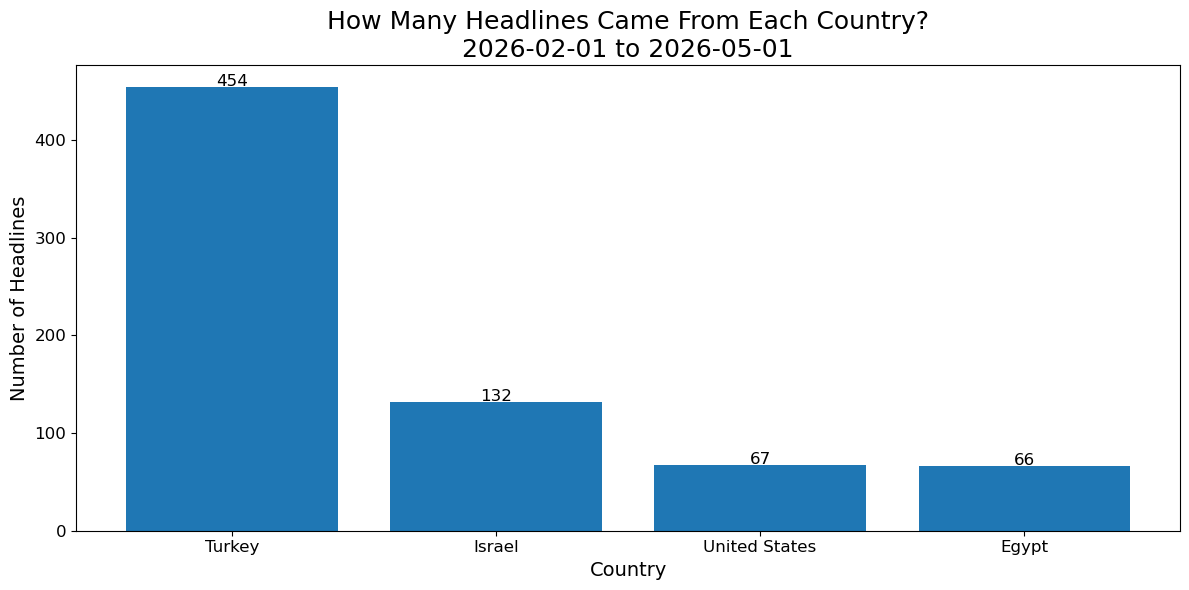

In [10]:
country_counts = vis_df["source_country"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(country_counts.index, country_counts.values)

plt.title(f"How Many Headlines Came From Each Country?\n{date_start} to {date_end}", fontsize=18)
plt.xlabel("Country", fontsize=14)
plt.ylabel("Number of Headlines", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        str(int(height)),
        ha="center",
        fontsize=12
    )

plt.tight_layout()
plt.show()

**Visualization 2: Monthly Coverage Trends**

This chart shows how Palestine-related headline volume changes over time by country. Coverage fluctuates across months, suggesting that media attention changes depending on timing and events.

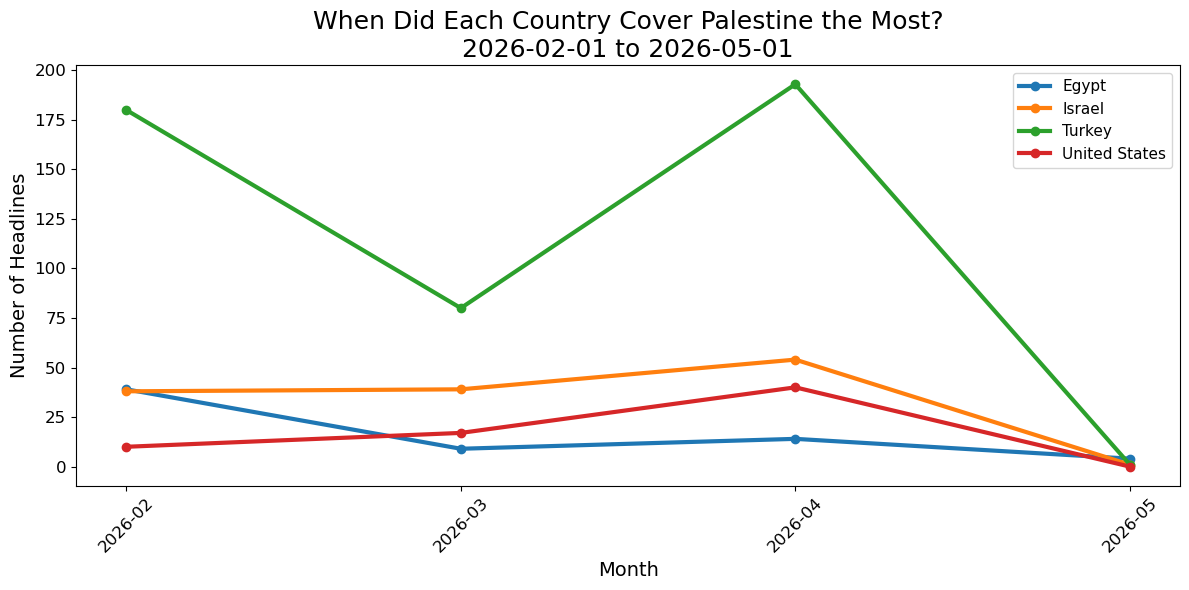

source_country,Egypt,Israel,Turkey,United States
month,,,,
2026-02,39,38,180,10
2026-03,9,39,80,17
2026-04,14,54,193,40
2026-05,4,1,1,0


In [11]:
monthly_counts = (
    vis_df.groupby(["month", "source_country"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

plt.figure(figsize=(12, 6))

for country in monthly_counts.columns:
    plt.plot(
        monthly_counts.index,
        monthly_counts[country],
        marker="o",
        linewidth=3,
        label=country
    )

plt.title(f"When Did Each Country Cover Palestine the Most?\n{date_start} to {date_end}", fontsize=18)
plt.xlabel("Month", fontsize=14)
plt.ylabel("Number of Headlines", fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

display(monthly_counts)

**Visualization 3: Topic Emphasis by Country**

This chart compares the types of Palestine-related stories emphasized by each country. Differences in categories such as politics, conflict, protest, and humanitarian issues suggest that countries may frame coverage in different ways.

topic_category  Conflict / Attack  Protest / Activism  Politics / Election  \
source_country                                                               
Egypt                           0                   0                    0   
Israel                          7                   1                   12   
Turkey                          7                  10                    2   
United States                  15                   1                   21   

topic_category  Aid / Humanitarian  
source_country                      
Egypt                            0  
Israel                           3  
Turkey                           1  
United States                    4  


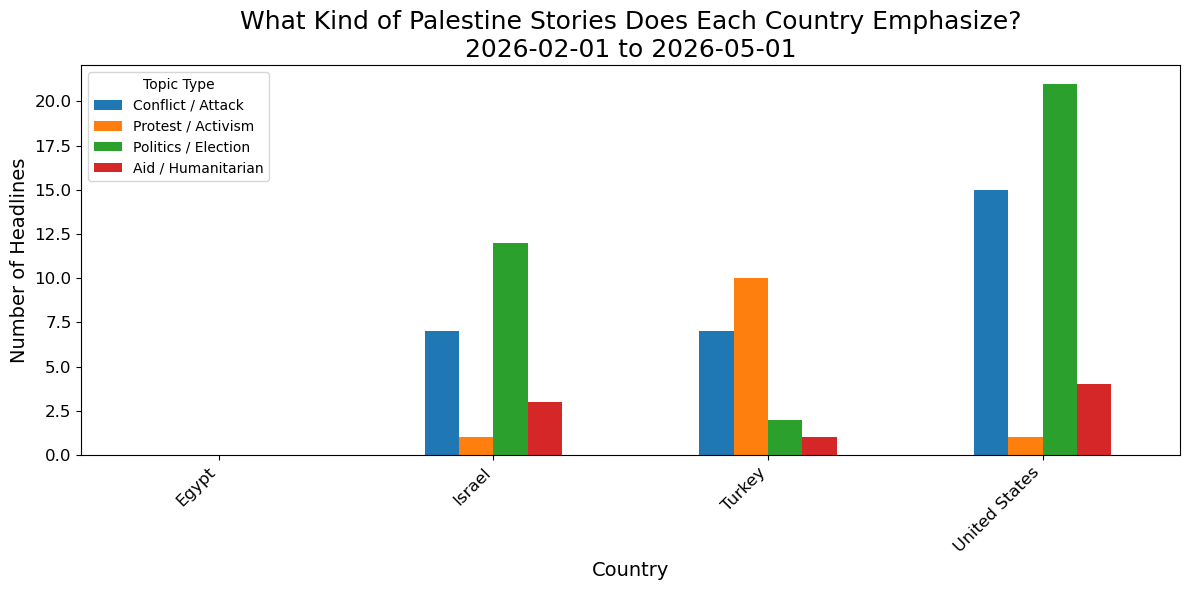

In [13]:
def classify_topic(headline):
    text = str(headline).lower()

    conflict_words = [
        "attack", "airstrike", "strike", "war", "battle", "bomb", "raid",
        "killed", "wounded", "military", "violence", "missile", "troops",
        "soldier", "clash", "fighting", "conflict"
    ]

    protest_words = [
        "protest", "rally", "march", "demonstration", "activist",
        "student", "campus", "solidarity", "boycott"
    ]

    politics_words = [
        "election", "vote", "government", "minister", "prime minister",
        "president", "parliament", "ceasefire", "deal", "negotiation",
        "talks", "policy", "official"
    ]

    humanitarian_words = [
        "aid", "hospital", "refugee", "humanitarian", "food", "water",
        "children", "civilian", "injured", "medical", "relief", "crisis",
        "hunger", "famine", "shelter"
    ]

    if any(word in text for word in conflict_words):
        return "Conflict / Attack"
    elif any(word in text for word in protest_words):
        return "Protest / Activism"
    elif any(word in text for word in politics_words):
        return "Politics / Election"
    elif any(word in text for word in humanitarian_words):
        return "Aid / Humanitarian"
    else:
        return "Other"


vis_df["topic_category"] = vis_df["title"].apply(classify_topic)

topic_counts = (
    vis_df.groupby(["source_country", "topic_category"])
    .size()
    .unstack(fill_value=0)
)

main_categories = [
    "Conflict / Attack",
    "Protest / Activism",
    "Politics / Election",
    "Aid / Humanitarian"
]

for category in main_categories:
    if category not in topic_counts.columns:
        topic_counts[category] = 0

topic_counts = topic_counts[main_categories]

print(topic_counts)

topic_counts.plot(kind="bar", figsize=(12, 6))

plt.title(f"What Kind of Palestine Stories Does Each Country Emphasize?\n{date_start} to {date_end}", fontsize=18)
plt.xlabel("Country", fontsize=14)
plt.ylabel("Number of Headlines", fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title="Topic Type", fontsize=10)
plt.tight_layout()
plt.show()

**Statistical Analysis: Headline Length Differences**

We used a Kruskal-Wallis test to compare headline length distributions across countries. This helps evaluate whether countries differ not only in coverage volume and topic emphasis, but also in headline structure.

In [14]:
length_groups = [
    vis_df.loc[vis_df["source_country"] == c, "headline_length_words"].values
    for c in vis_df["source_country"].value_counts().index.tolist()
]

kw_stat, kw_p = kruskal(*length_groups)

print("Kruskal-Wallis statistic:", round(kw_stat, 4))
print("p-value:", round(kw_p, 6))

Kruskal-Wallis statistic: 22.9562
p-value: 4.1e-05


## Machine Learning

We converted and cleaned headline text into TF-IDF features and trained classification models to predict the source country. We used a balanced subset of the top countries so the model would not simply learn to favor the most common country.

In [15]:
X = df_ml["clean_text"]
y = df_ml["source_country"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

vectorizer = TfidfVectorizer(max_features=4000, ngram_range=(1, 2), min_df=1)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Countries used for ML:")
print(df_ml["source_country"].value_counts())
print("Training shape:", X_train_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)

Countries used for ML:
source_country
Turkey           67
Israel           67
United States    67
Name: count, dtype: int64
Training shape: (150, 2129)
Test shape: (51, 2129)


**Logistic Regression Results**

The Logistic Regression model achieved an accuracy of approximately 0.90, significantly outperforming the baseline accuracy of 0.33. This indicates that the model is learning meaningful patterns from the headline text.

The classification report shows strong performance across all countries, with high precision, recall, and F1-scores.

In [16]:
baseline_label = y_train.mode()[0]
baseline_preds = np.full(len(y_test), baseline_label)
baseline_acc = accuracy_score(y_test, baseline_preds)

log_reg = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
log_reg.fit(X_train_tfidf, y_train)
log_preds = log_reg.predict(X_test_tfidf)
log_acc = accuracy_score(y_test, log_preds)

print("Baseline label:", baseline_label)
print("Baseline accuracy:", round(baseline_acc, 4))
print("Logistic Regression accuracy:", round(log_acc, 4))

log_report = pd.DataFrame(
    classification_report(y_test, log_preds, zero_division=0, output_dict=True)
).transpose().round(3)

print("\nLogistic Regression Accuracy Report:")
display(log_report)

Baseline label: Israel
Baseline accuracy: 0.3333
Logistic Regression accuracy: 0.902

Logistic Regression Accuracy Report:


,precision,recall,f1-score,support
Israel,0.833,0.882,0.857,17.000
Turkey,1.000,0.941,0.970,17.000
United States,0.882,0.882,0.882,17.000
accuracy,0.902,0.902,0.902,0.902
macro avg,0.905,0.902,0.903,51.000
weighted avg,0.905,0.902,0.903,51.000


**Naive Bayes Results and Model Comparison**

The Naive Bayes model achieved an accuracy of approximately 0.88, also outperforming the baseline but slightly below Logistic Regression.

The comparison chart shows that both models significantly outperform the baseline, with Logistic Regression performing the best overall. This suggests that headline wording contains patterns that can distinguish between countries.

Naive Bayes accuracy: 0.8824

Naive Bayes Accuracy Report:


,precision,recall,f1-score,support
Israel,0.875,0.824,0.848,17.000
Turkey,1.000,0.882,0.938,17.000
United States,0.800,0.941,0.865,17.000
accuracy,0.882,0.882,0.882,0.882
macro avg,0.892,0.882,0.884,51.000
weighted avg,0.892,0.882,0.884,51.000


,Model,Accuracy
1,Logistic Regression,0.901961
2,Naive Bayes,0.882353
0,Baseline,0.333333


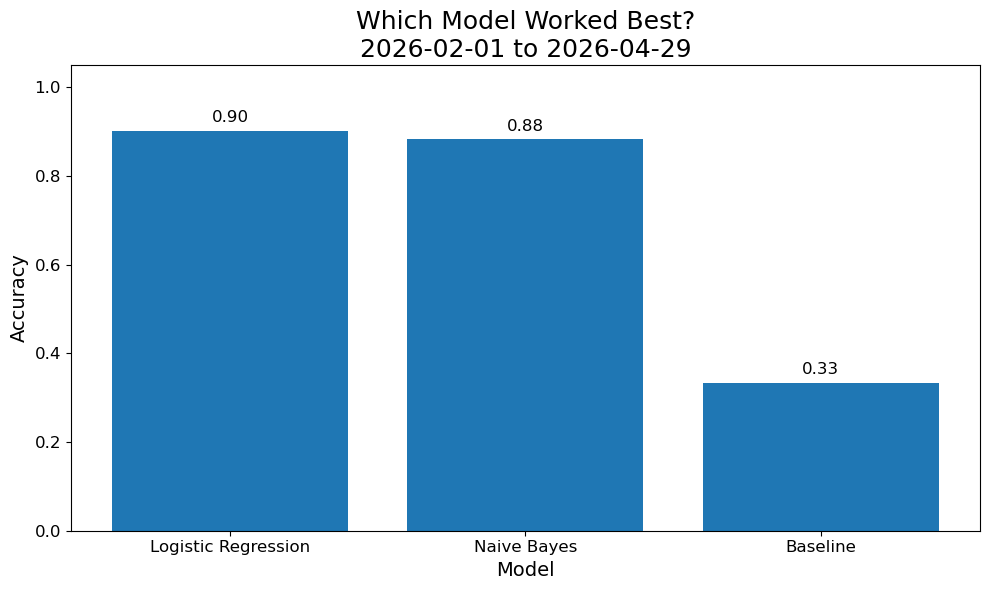

In [17]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_preds = nb_model.predict(X_test_tfidf)
nb_acc = accuracy_score(y_test, nb_preds)

print("Naive Bayes accuracy:", round(nb_acc, 4))

nb_report = pd.DataFrame(
    classification_report(y_test, nb_preds, zero_division=0, output_dict=True)
).transpose().round(3)

print("\nNaive Bayes Accuracy Report:")
display(nb_report)

comparison_df = pd.DataFrame({
    "Model": ["Baseline", "Logistic Regression", "Naive Bayes"],
    "Accuracy": [baseline_acc, log_acc, nb_acc]
}).sort_values("Accuracy", ascending=False)

display(comparison_df)

ml_date_start = df_ml["date"].min().date()
ml_date_end = df_ml["date"].max().date()

plt.figure(figsize=(10, 6))
bars = plt.bar(comparison_df["Model"], comparison_df["Accuracy"])

plt.title(f"Which Model Worked Best?\n{ml_date_start} to {ml_date_end}", fontsize=18)
plt.xlabel("Model", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.ylim(0, 1.05)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.02,
        f"{height:.2f}",
        ha="center",
        fontsize=12
    )

plt.tight_layout()
plt.show()

**Model Performance by Country**

This chart shows the F1-score for each model across different countries. Both models perform well across all classes, with Logistic Regression slightly outperforming Naive Bayes.

This indicates that the models are consistently able to distinguish between countries based on headline text.

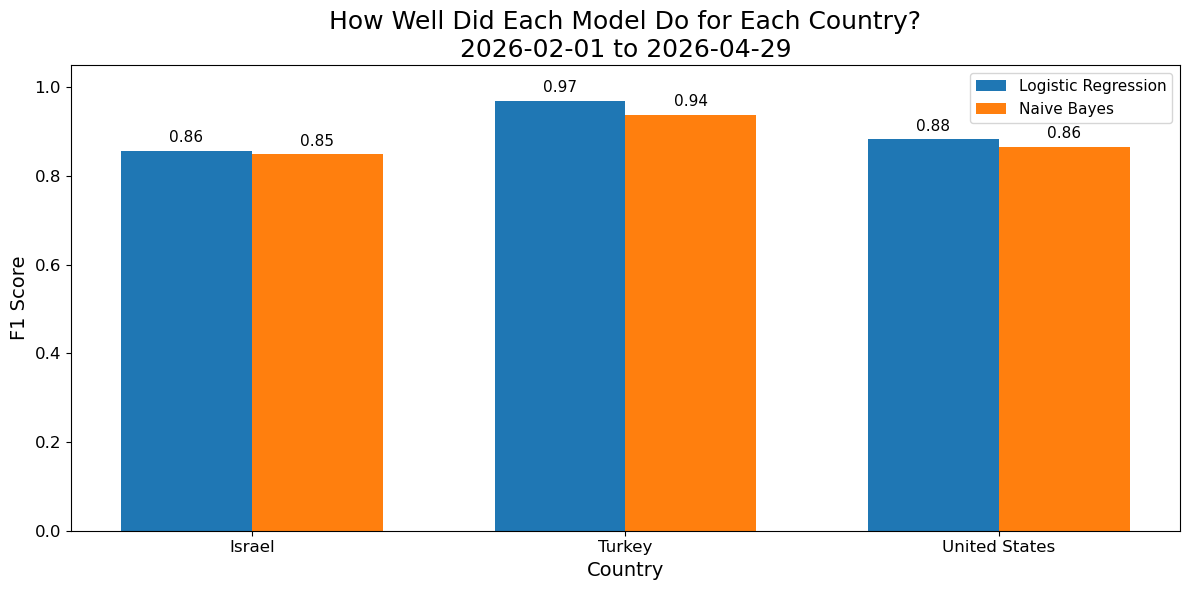

In [18]:
log_report_dict = classification_report(
    y_test, log_preds, zero_division=0, output_dict=True
)
nb_report_dict = classification_report(
    y_test, nb_preds, zero_division=0, output_dict=True
)

class_labels = sorted(list(set(y_test)))

log_f1 = [log_report_dict[label]["f1-score"] for label in class_labels]
nb_f1 = [nb_report_dict[label]["f1-score"] for label in class_labels]

x = np.arange(len(class_labels))
width = 0.35

plt.figure(figsize=(12, 6))
bars1 = plt.bar(x - width / 2, log_f1, width, label="Logistic Regression")
bars2 = plt.bar(x + width / 2, nb_f1, width, label="Naive Bayes")

plt.title(f"How Well Did Each Model Do for Each Country?\n{ml_date_start} to {ml_date_end}", fontsize=18)
plt.xlabel("Country", fontsize=14)
plt.ylabel("F1 Score", fontsize=14)
plt.xticks(x, class_labels, fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0, 1.05)
plt.legend(fontsize=11)

for bar in list(bars1) + list(bars2):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.02,
        f"{height:.2f}",
        ha="center",
        fontsize=11
    )

plt.tight_layout()
plt.show()

## Results

Overall, both machine learning models significantly outperformed the baseline, demonstrating that headline text contains identifiable patterns that differ across countries.

Logistic Regression achieved the highest accuracy at approximately 0.90, followed by Naive Bayes at 0.88. These results suggest that differences in wording and emphasis across countries can be captured using machine learning techniques.

However, results are still influenced by dataset limitations, including class overlap and multilingual content.